<a href="https://colab.research.google.com/github/Ramses-Monjaras/Data-Processing-Visualization/blob/main/Recreating_the_Masters_Final_Version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tokyo 2020 Olympic Medal
## Ramses Monjaras
##Data Processing Visualization
##CPSMA-4313-01
##Nicholas Jacob

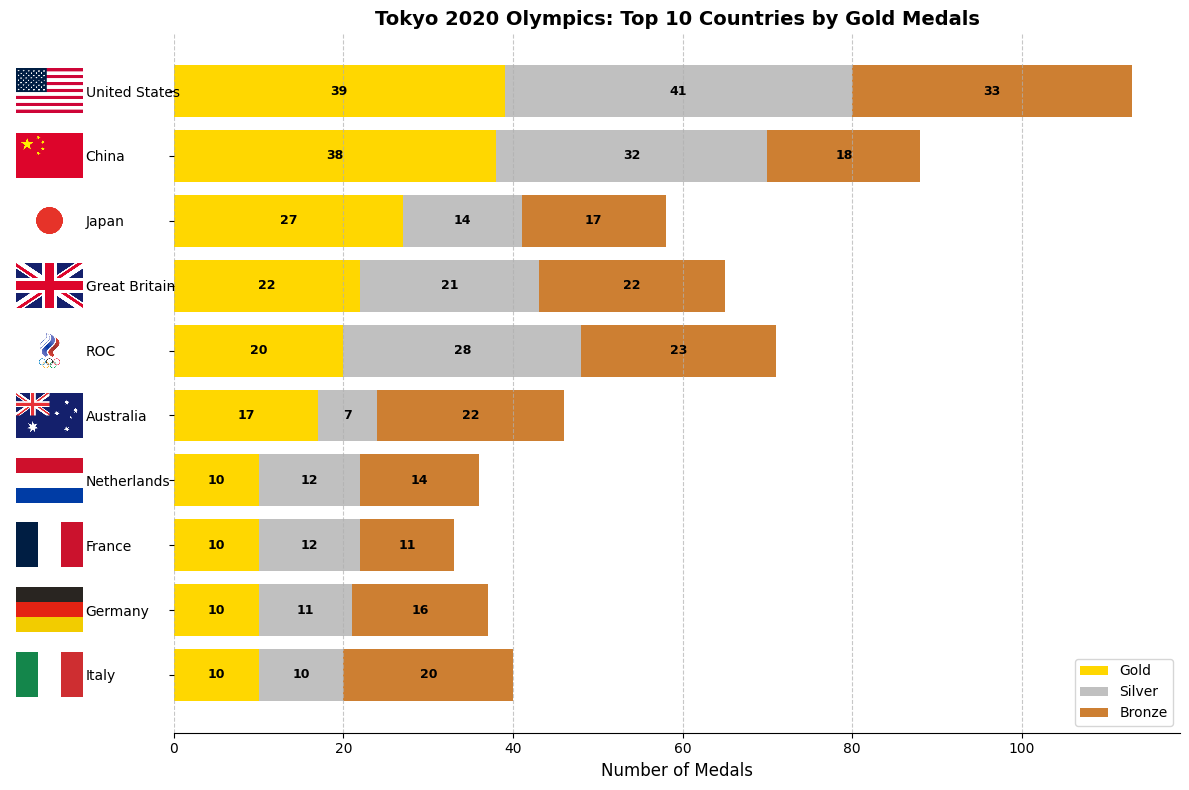

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import urllib.request
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

data = {
    'Country': ['United States', 'China', 'Japan', 'Great Britain', 'ROC', 'Australia', 'Netherlands', 'France', 'Germany', 'Italy'],
    'Gold': [39, 38, 27, 22, 20, 17, 10, 10, 10, 10],
    'Silver': [41, 32, 14, 21, 28, 7, 12, 12, 11, 10],
    'Bronze': [33, 18, 17, 22, 23, 22, 14, 11, 16, 20]
}

df = pd.DataFrame(data)

df = df.sort_values('Gold', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#FFD700', '#C0C0C0', '#CD7F32']

bars_gold = ax.barh(df['Country'], df['Gold'], color=colors[0], label='Gold')
bars_silver = ax.barh(df['Country'], df['Silver'], left=df['Gold'], color=colors[1], label='Silver')
bars_bronze = ax.barh(df['Country'], df['Bronze'], left=df['Gold'] + df['Silver'], color=colors[2], label='Bronze')

ax.set_xlabel('Number of Medals', fontsize=12)
ax.set_title('Tokyo 2020 Olympics: Top 10 Countries by Gold Medals', fontsize=14, fontweight='bold')

ax.legend(loc='lower right')

for index, row in df.iterrows():
    gold = row['Gold']
    silver = row['Silver']
    bronze = row['Bronze']

    if gold > 0:
        x_pos_gold = gold / 2
        ax.text(x_pos_gold, index, f'{gold}', va='center', ha='center',
                color='black', fontweight='bold', fontsize=9)

    if silver > 0:
        x_pos_silver = gold + (silver / 2)
        ax.text(x_pos_silver, index, f'{silver}', va='center', ha='center',
                color='black', fontweight='bold', fontsize=9)

    if bronze > 0:
        x_pos_bronze = gold + silver + (bronze / 2)
        ax.text(x_pos_bronze, index, f'{bronze}', va='center', ha='center',
                color='black', fontweight='bold', fontsize=9)

ax.invert_yaxis()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.xaxis.grid(True, linestyle='--', alpha=0.7)


ax.set_yticks(np.arange(len(df)))
ax.set_yticklabels(df['Country'], ha='left')
ax.tick_params(axis='y', pad=60)

for i, country in enumerate(df['Country']):
    flag_img = None
    if country == 'United States':
            flag_img = Image.open('/USA.png')

    if country == 'China':
            flag_img = Image.open('/CHN.png')

    if country == 'Japan':
            flag_img = Image.open('/JPN.png')

    if country == 'Great Britain':
            flag_img = Image.open('/GBR.png')

    if country == 'ROC':
            flag_img = Image.open('/ROC.png')

    if country == 'Australia':
            flag_img = Image.open('/AUS.png')

    if country == 'Netherlands':
            flag_img = Image.open('/NED.png')

    if country == 'France':
            flag_img = Image.open('/FRA.png')

    if country == 'Germany':
            flag_img = Image.open('/GER.png')

    if country == 'Italy':
            flag_img = Image.open('/ITA.png')

    if flag_img:

        imagebox = OffsetImage(flag_img, zoom=0.2)
        ab = AnnotationBbox(imagebox, xy=(0, i), xybox=(-90, 0),
                            xycoords='data', boxcoords='offset points',
                            frameon=False)
        ax.add_artist(ab)

plt.tight_layout()
plt.show()

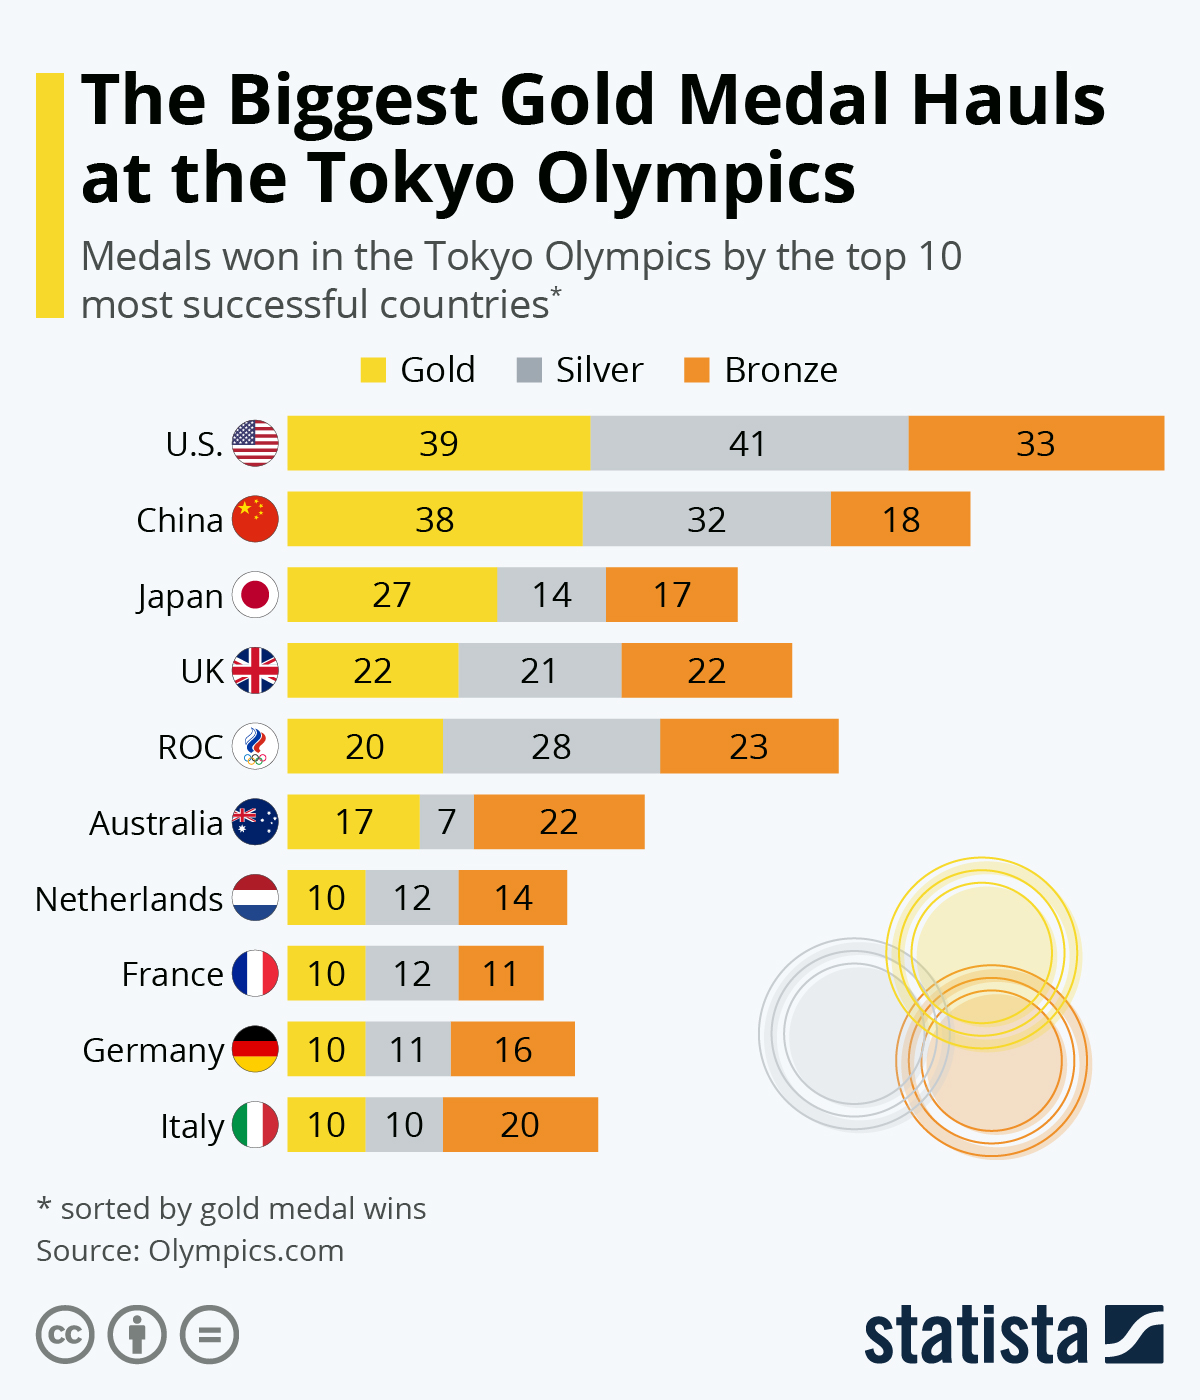

Link: https://www.statista.com/chart/25461/medal-count-tokyo-olympics-2020-21/?srsltid=AfmBOor0lRirAs6g7POWhsJyK0kuETrGIWcjdsZeLtIm6g9sDI4zZw1R

I found 'from PIL import Image' to be useful because it allowed me to locally import images to the graph. I also use 'from matplotlib.offsetbox import OffsetImage, AnnotationBbox', this allows me to place the image anywhere in the graph thus making it easier to place the country's flag next their name. I found the original visualization to be a good one because it is clean and simple to understand with enough data to know what the graph is trying to say. This data doesn't need any cleaning. My recreation of the visualization is a bit different from the original, I display the number of medals as well as a grid to easily see the total number of medals won. The look and the placement of the flag is different from the original.